# CIFAR-10 Image Classification with CNN

In previous weeks, we tested different models for image classification:

- FCNN with MNIST
- FCNN with CIFAR-10
- SIFT + FCNN
- Dense SIFT + FCNN

These experiments showed that feature representation is very important for image classification.

In this notebook, we use a Convolutional Neural Network (CNN) on CIFAR-10.  
Unlike SIFT-based methods, CNN learns image features automatically using convolutional filters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Load CIFAR-10 Dataset

CIFAR-10 is an image classification dataset.

It has 10 classes:

airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck.

Each image has size 32x32 with 3 color channels.

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

y_train = y_train.reshape(-1)
y_test = y_test.reshape(-1)

class_names = ["airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"]

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2830s 17us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000,)
Test images: (10000, 32, 32, 3)
Test labels: (10000,)


## 2. Visualize Sample Images

Before building the model, we look at some sample images.

This helps us understand why CIFAR-10 is harder than MNIST.  
The images are small, colorful, and the objects have more complex shapes.

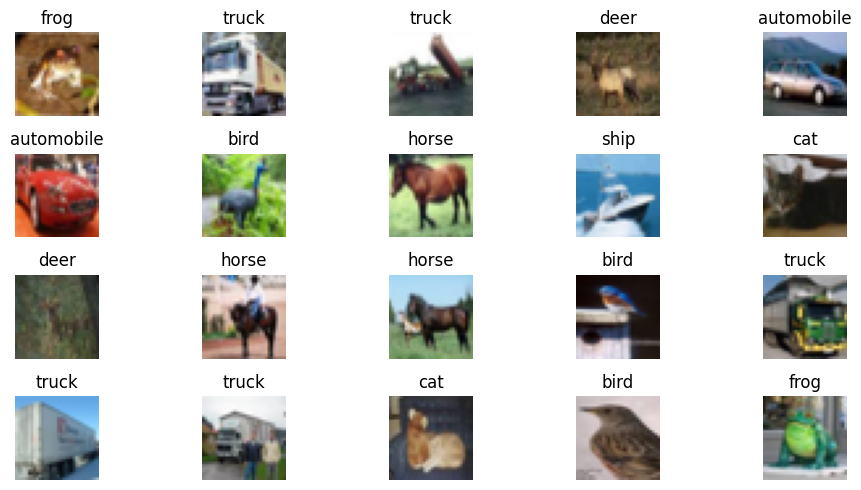

In [3]:
plt.figure(figsize=(10, 5))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Normalize Pixel Values

Neural networks train better when input values are small.

The original pixel values are between 0 and 255.  
We divide them by 255 so that all pixel values become between 0 and 1.

In [4]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


## 4. Data Augmentation

CNNs can overfit if they memorize training images.

Data augmentation creates slightly changed versions of images during training.  
For example, images can be flipped, shifted, or rotated.

This helps the model generalize better.

In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomRotation(0.05),
], name="data_augmentation")

## 5. Build CNN Model

A CNN learns image features automatically.

Main components:

- Convolution layer: extracts local features using filters/kernels
- ReLU activation: adds non-linearity
- Max pooling: reduces image size and keeps important features
- Flatten: converts feature maps into a vector
- Dense layer: performs classification
- Softmax: gives probability for each class

In [6]:
cnn_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.40),

    layers.Flatten(),

    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.50),

    layers.Dense(10, activation="softmax")
])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,02

 Total params: 816,938 (3.12 MB)

 Trainable params: 815,530 (3.11 MB)

 Non-trainable params: 1,408 (5.50 KB)

## 6. Compile the Model

Before training, we compile the model.

We use:

- Adam optimizer: updates model weights
- Sparse categorical crossentropy: loss function for multi-class classification
- Accuracy: evaluation metric

In [7]:
cnn_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy", metrics=["accuracy"])

## 7. Train the CNN Model

Now we train the CNN on CIFAR-10.

During training, the model learns convolution filters.  
These filters detect useful patterns such as edges, textures, shapes, and object parts.

In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = cnn_model.fit(
    x_train,
    y_train,
    epochs=35,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 442s 695ms/step - accuracy: 0.3609 - loss: 1.8927 - val_accuracy: 0.2976 - val_loss: 2.1968 - learning_rate: 0.0010
Epoch 2/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 414s 650ms/step - accuracy: 0.5023 - loss: 1.3771 - val_accuracy: 0.5607 - val_loss: 1.2376 - learning_rate: 0.0010
Epoch 3/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 466s 689ms/step - accuracy: 0.5673 - loss: 1.2014 - val_accuracy: 0.6317 - val_loss: 1.0590 - learning_rate: 0.0010
Epoch 4/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 424s 661ms/step - accuracy: 0.6115 - loss: 1.0897 - val_accuracy: 0.6300 - val_loss: 1.0763 - learning_rate: 0.0010
Epoch 5/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 461s 691ms/step - accuracy: 0.6467 - loss: 1.0071 - val_accuracy: 0.6412 - val_loss: 1.0092 - learning_rate: 0.0010
Epoch 6/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 426s 682ms/step - accuracy: 0.6647 - loss: 0.9472 - val_accuracy: 0.6509 - val_loss: 1.0237 - learning_rate: 0.0010
Epoch 7/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 422s 650ms/step - accura

## 8. Evaluate the Model

After training, we test the model on unseen test images.

This tells us how well the CNN generalizes to new CIFAR-10 images.

In [9]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=7,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5
)

history = cnn_model.fit(
    x_train,
    y_train,
    epochs=35,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 401s 642ms/step - accuracy: 0.8361 - loss: 0.4736 - val_accuracy: 0.8460 - val_loss: 0.4481 - learning_rate: 6.2500e-05
Epoch 2/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 462s 674ms/step - accuracy: 0.8382 - loss: 0.4654 - val_accuracy: 0.8422 - val_loss: 0.4583 - learning_rate: 6.2500e-05
Epoch 3/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 421s 674ms/step - accuracy: 0.8376 - loss: 0.4736 - val_accuracy: 0.8448 - val_loss: 0.4556 - learning_rate: 6.2500e-05
Epoch 4/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 440s 670ms/step - accuracy: 0.8369 - loss: 0.4716 - val_accuracy: 0.8461 - val_loss: 0.4492 - learning_rate: 6.2500e-05
Epoch 5/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 424s 642ms/step - accuracy: 0.8410 - loss: 0.4659 - val_accuracy: 0.8478 - val_loss: 0.4481 - learning_rate: 3.1250e-05
Epoch 6/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 460s 672ms/step - accuracy: 0.8407 - loss: 0.4622 - val_accuracy: 0.8486 - val_loss: 0.4440 - learning_rate: 3.1250e-05
Epoch 7/35
625/625 ━━━━━━━━━━━━━━━━━━━━ 

## 8. Evaluate the Model

After training, we test the model on unseen test images.

This tells us how well the CNN generalizes to new CIFAR-10 images.

In [10]:
test_loss, test_accuracy = cnn_model.evaluate(x_test, y_test, verbose=1)

print("CNN Test Loss:", test_loss)
print("CNN Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.8464 - loss: 0.4609
CNN Test Loss: 0.46091601252555847
CNN Test Accuracy: 0.8464000225067139


## 9. Accuracy and Loss Curves

These graphs show the training process.

If training accuracy is much higher than validation accuracy, the model may be overfitting.  
If both improve together, the model is learning useful patterns.

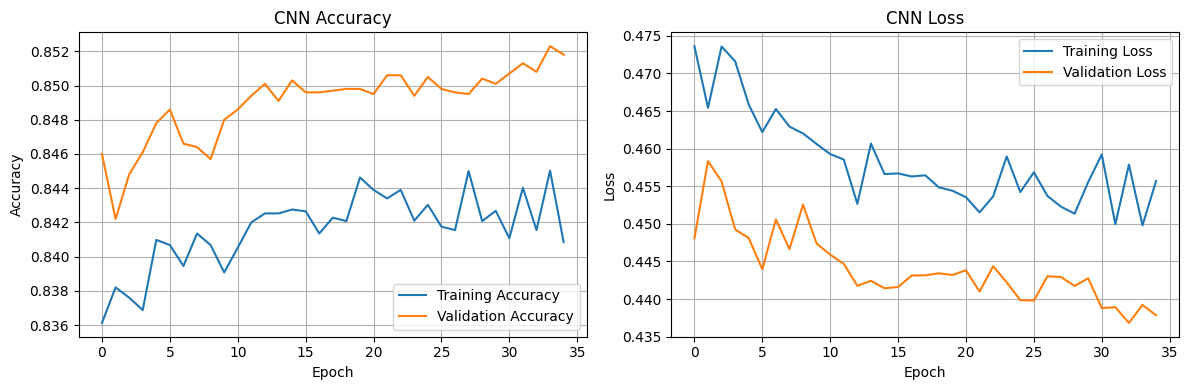

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 10. Classification Report

The classification report shows precision, recall, and F1-score for each class.

This helps us understand which classes the CNN predicts well and which classes are difficult.

In [12]:
y_pred_prob = cnn_model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 74ms/step
              precision    recall  f1-score   support

    airplane       0.87      0.86      0.87      1000
  automobile       0.93      0.94      0.93      1000
        bird       0.85      0.76      0.80      1000
         cat       0.78      0.64      0.70      1000
        deer       0.83      0.83      0.83      1000
         dog       0.84      0.73      0.78      1000
        frog       0.74      0.95      0.84      1000
       horse       0.87      0.90      0.88      1000
        ship       0.92      0.91      0.92      1000
       truck       0.84      0.94      0.89      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.84     10000
weighted avg       0.85      0.85      0.84     10000



## 11. Confusion Matrix

The confusion matrix shows where the model makes mistakes.

For example, cats and dogs may be confused because they have similar visual features.

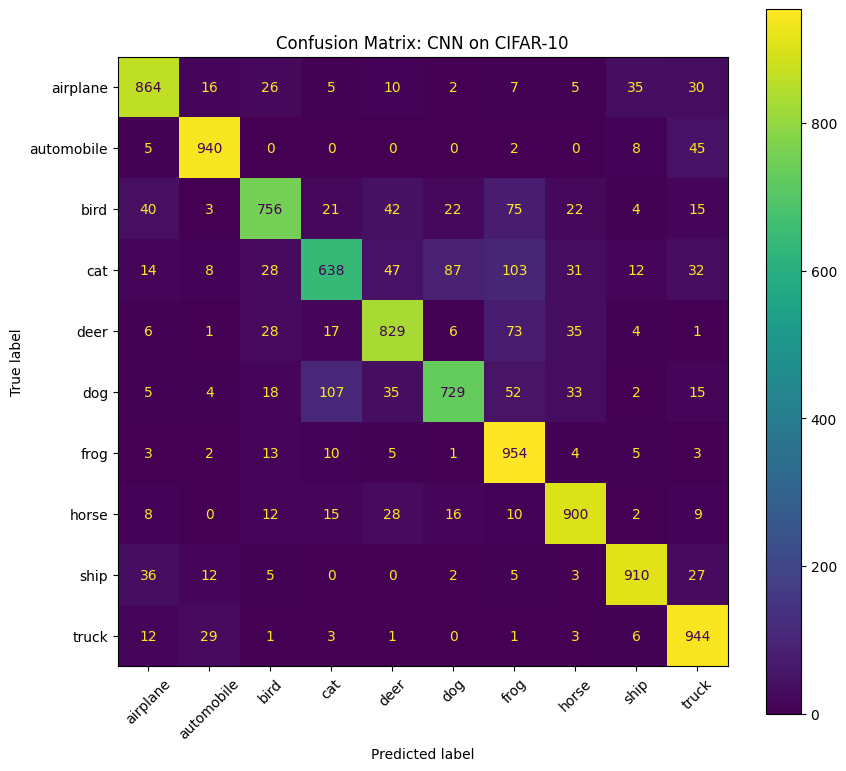

In [13]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(9, 8))

display.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title("Confusion Matrix: CNN on CIFAR-10")
plt.tight_layout()
plt.show()

## 12. Show Example Predictions

Here we visualize some test images with their predicted labels.

This gives a more intuitive understanding of the model's performance.

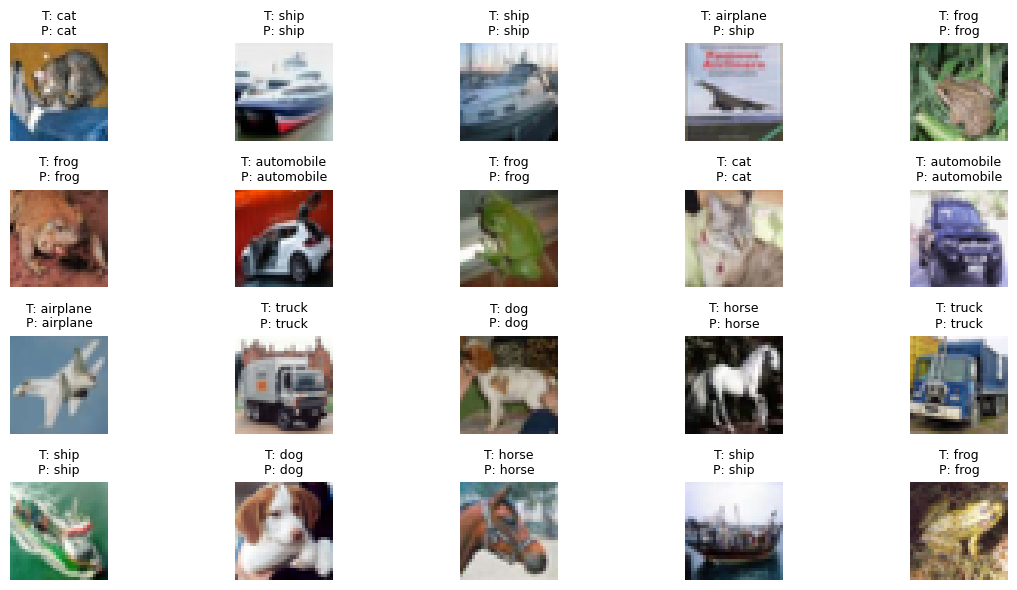

In [14]:
plt.figure(figsize=(12, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[i])

    true_label = class_names[y_test[i]]
    predicted_label = class_names[y_pred[i]]

    title = f"T: {true_label}\nP: {predicted_label}"
    plt.title(title, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 13. Compare All Models

Now we compare CNN with previous models.

Previous models:

- MNIST FCNN
- CIFAR-10 Raw Pixel FCNN
- CIFAR-10 SIFT Mean + FCNN
- CIFAR-10 Dense SIFT + FCNN

CNN should perform better because it learns visual features directly from images.

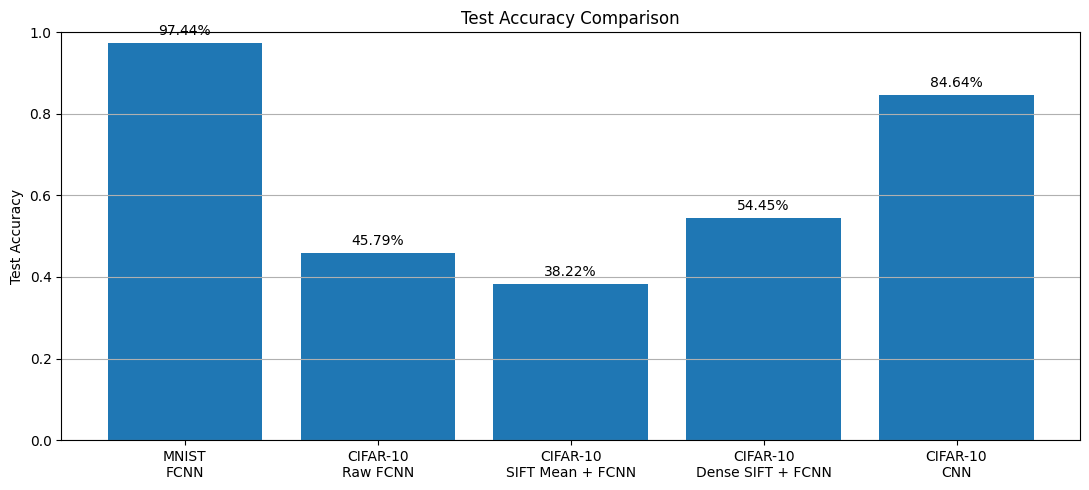

MNIST FCNN Accuracy: 0.9744
CIFAR-10 Raw FCNN Accuracy: 0.4579
CIFAR-10 SIFT Mean + FCNN Accuracy: 0.3822
CIFAR-10 Dense SIFT + FCNN Accuracy: 0.5445
CIFAR-10 CNN Accuracy: 0.8464000225067139


In [15]:
mnist_fcnn_accuracy = 0.9744
cifar_raw_fcnn_accuracy = 0.4579
cifar_sift_mean_fcnn_accuracy = 0.3822
cifar_dense_sift_fcnn_accuracy = 0.5445
cifar_cnn_accuracy = test_accuracy

models_list = [
    "MNIST\nFCNN",
    "CIFAR-10\nRaw FCNN",
    "CIFAR-10\nSIFT Mean + FCNN",
    "CIFAR-10\nDense SIFT + FCNN",
    "CIFAR-10\nCNN"
]

accuracies = [
    mnist_fcnn_accuracy,
    cifar_raw_fcnn_accuracy,
    cifar_sift_mean_fcnn_accuracy,
    cifar_dense_sift_fcnn_accuracy,
    cifar_cnn_accuracy
]

plt.figure(figsize=(11, 5))
plt.bar(models_list, accuracies)

plt.title("Test Accuracy Comparison")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1)

for i, value in enumerate(accuracies):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

plt.grid(axis="y")
plt.tight_layout()
plt.show()

print("MNIST FCNN Accuracy:", mnist_fcnn_accuracy)
print("CIFAR-10 Raw FCNN Accuracy:", cifar_raw_fcnn_accuracy)
print("CIFAR-10 SIFT Mean + FCNN Accuracy:", cifar_sift_mean_fcnn_accuracy)
print("CIFAR-10 Dense SIFT + FCNN Accuracy:", cifar_dense_sift_fcnn_accuracy)
print("CIFAR-10 CNN Accuracy:", cifar_cnn_accuracy)

## 14. Conclusion

The previous experiments showed that image classification depends strongly on feature representation.

SIFT and Dense SIFT use handcrafted feature extraction.  
This means the features are designed manually before training the classifier.

CNN uses a different approach.  
It learns filters automatically during training.

This is the main advantage of CNNs:

Instead of manually designing image features, CNN learns useful visual patterns directly from data.

Final Explanation:

In previous experiments, we used FCNN, SIFT + FCNN, and Dense SIFT + FCNN.

The Dense SIFT model improved the result because it extracted stronger handcrafted features.
However, it still required manual feature engineering.

In this experiment, we used a CNN on CIFAR-10.

CNN uses convolutional filters to learn features automatically from images.
Early convolution layers can learn simple patterns such as edges and textures.
Deeper layers can learn more complex patterns such as object parts.

This makes CNN more suitable for image recognition tasks than a simple FCNN or handcrafted SIFT-based pipeline.